In [5]:
import pandas as pd 
import matplotlib.pyplot as plt

# Import data

In [11]:
# Variable array size runtime data
var_arr_size = pd.read_csv('results.csv')
var_max_val = pd.read_csv('results_maxval.csv')

In [12]:
var_max_val

,node,size,max_value,rep,real_s,user_s,sys_s
0,soctf-pdc-002.comp.nus.edu.sg,20000,10,1,1.07,1.06,0.0
1,soctf-pdc-002.comp.nus.edu.sg,20000,10,2,1.07,1.06,0.0
2,soctf-pdc-002.comp.nus.edu.sg,20000,10,3,1.06,1.04,0.0
3,soctf-pdc-002.comp.nus.edu.sg,20000,10,4,1.04,1.03,0.0
4,soctf-pdc-002.comp.nus.edu.sg,20000,10,5,1.04,1.03,0.0
5,soctf-pdc-002.comp.nus.edu.sg,20000,10,6,1.08,1.06,0.0
6,soctf-pdc-002.comp.nus.edu.sg,20000,10,7,1.05,1.04,0.0
7,soctf-pdc-002.comp.nus.edu.sg,20000,10,8,1.05,1.03,0.0
8,soctf-pdc-002.comp.nus.edu.sg,20000,10,9,1.04,1.03,0.0
9,soctf-pdc-002.comp.nus.edu.sg,20000,10,10,1.07,1.06,0.0


# Visualise data 

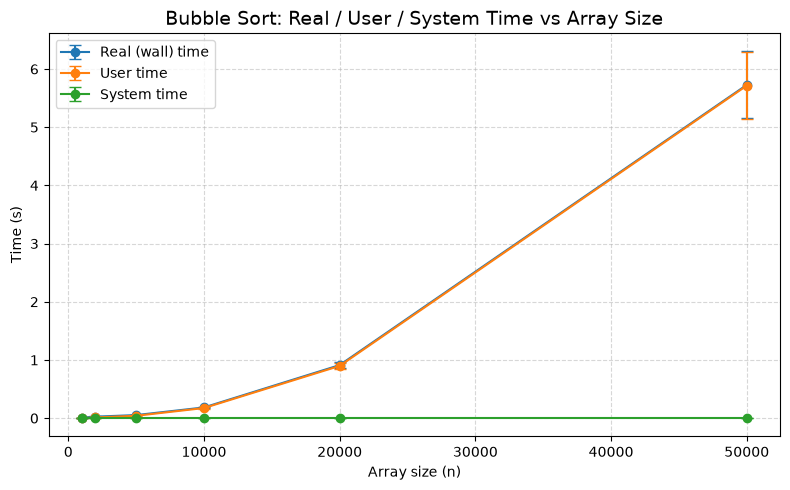

In [10]:
metrics = {
    "real_s": "Real (wall) time",
    "user_s": "User time",
    "sys_s":  "System time",
}

fig, ax = plt.subplots(figsize=(8, 5))

for col, label in metrics.items():
    grouped = var_arr_size.groupby("size")[col]
    sizes = grouped.mean().index
    means = grouped.mean().values
    stds  = grouped.std().values
    ax.errorbar(sizes, means, yerr=stds,
                marker="o", markersize=6, capsize=4,
                linewidth=1.5, label=label)

ax.set_title("Bubble Sort: Real / User / System Time vs Array Size", fontsize=14)
ax.set_xlabel("Array size (n)")
ax.set_ylabel("Time (s)")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig("runtime_multiline.png", dpi=150)
plt.show()

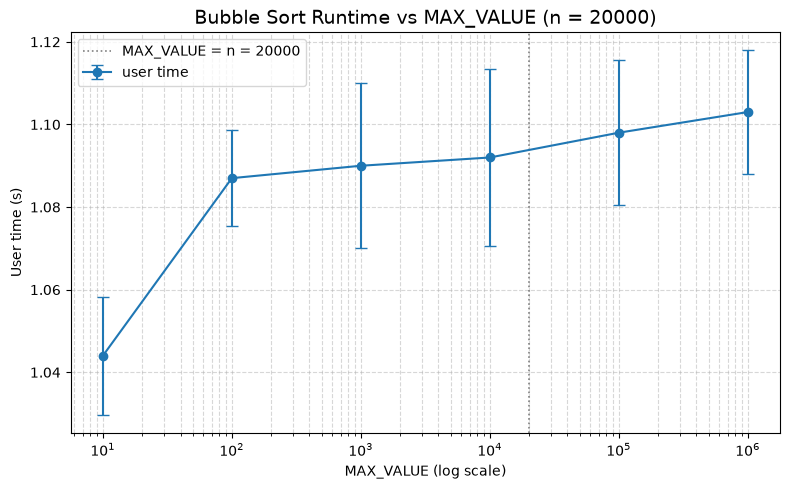

In [15]:
# visualise the variable max value 
grouped = var_max_val.groupby("max_value")["user_s"]
maxvals = grouped.mean().index
means   = grouped.mean().values
stds    = grouped.std().values

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(maxvals, means, yerr=stds,
            marker="o", markersize=6, capsize=4,
            linewidth=1.5, label="user time")

# x spans 10 -> 1e6, so log scale
ax.set_xscale("log")

# mark the MAX_VALUE = n boundary (n fixed at 20000)
n_fixed = var_max_val["size"].iloc[0]
ax.axvline(n_fixed, color="grey", linestyle=":", linewidth=1.2,
           label=f"MAX_VALUE = n = {n_fixed}")

ax.set_title(f"Bubble Sort Runtime vs MAX_VALUE (n = {n_fixed})", fontsize=14)
ax.set_xlabel("MAX_VALUE (log scale)")
ax.set_ylabel("User time (s)")
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig("runtime_vs_maxval.png", dpi=150)
plt.show()

# Optimisation 

In [16]:
optimised_run_time = pd.read_csv('optimised_sort_results.csv')

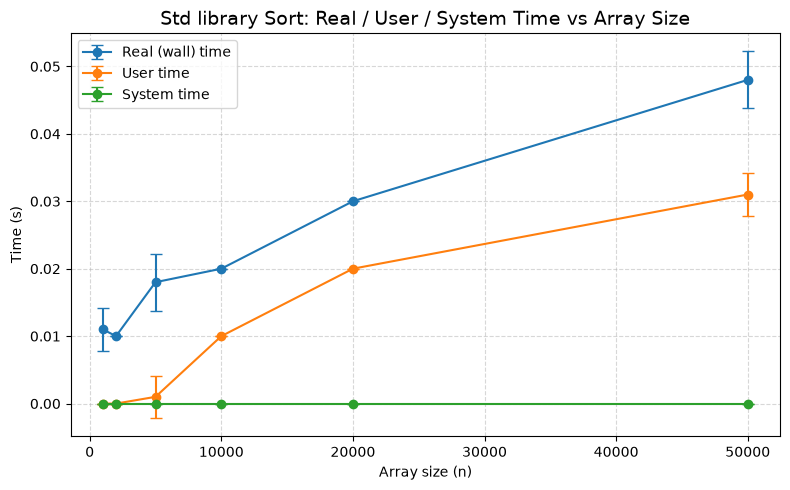

In [17]:
metrics = {
    "real_s": "Real (wall) time",
    "user_s": "User time",
    "sys_s":  "System time",
}

fig, ax = plt.subplots(figsize=(8, 5))

for col, label in metrics.items():
    grouped = optimised_run_time.groupby("size")[col]
    sizes = grouped.mean().index
    means = grouped.mean().values
    stds  = grouped.std().values
    ax.errorbar(sizes, means, yerr=stds,
                marker="o", markersize=6, capsize=4,
                linewidth=1.5, label=label)

ax.set_title("Std library Sort: Real / User / System Time vs Array Size", fontsize=14)
ax.set_xlabel("Array size (n)")
ax.set_ylabel("Time (s)")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig("runtime_multiline.png", dpi=150)
plt.show()